# `GenVarLoader`

In [1]:
# Automatically reload code in notebook
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import pandas as pd
import polars as pl
# pip install git+https://github.com/mcvickerlab/GenVarLoader.git@dlaub/dlaub-splice --force-reinstall
import genvarloader as gvl
import seqpro as sp
import pooch
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.genvarloader as GVL

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Test splicing

https://github.com/mcvickerlab/GenVarLoader/blob/dlaub/splice/docs/source/splicing.ipynb

### Import GTF

In [2]:
# From Ensembl FTP: https://ftp.ensembl.org/pub/release-113/gtf/homo_sapiens/
gtf_path = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-113/gtf/homo_sapiens/Homo_sapiens.GRCh38.113.chr_patch_hapl_scaff.gtf.gz",
    known_hash="670d0572422b315124770d1dff1613ff5b563b965de48d8f35cccdef892bfc35",
    progressbar=True,
    fname="Homo_sapiens.GRCh38.113.chr_patch_hapl_scaff.gtf.gz",
)

In [3]:
import gtfparse

gtf = gtfparse.read_gtf(
    gtf_path,
    features=["exon"]
    )
gtf.head()

INFO:root:Extracted GTF attributes: ['gene_id', 'gene_version', 'transcript_id', 'transcript_version', 'exon_number', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_name', 'transcript_source', 'transcript_biotype', 'exon_id', 'exon_version', 'tag', 'transcript_support_level', 'ccds_id']


seqname,source,feature,start,end,score,strand,frame,gene_id,gene_version,transcript_id,transcript_version,exon_number,gene_name,gene_source,gene_biotype,transcript_name,transcript_source,transcript_biotype,exon_id,exon_version,tag,transcript_support_level,ccds_id
cat,cat,cat,i64,i64,f32,cat,u32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""1""","""havana""","""exon""",3069168,3069296,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""1""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00002048533""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3186125,3186474,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""2""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00001754112""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3244087,3244137,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""3""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00003480863""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3385149,3385286,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""4""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00002034212""","""1""","""gencode_basic,gencode_primary""","""5""",""""""
"""1""","""havana""","""exon""",3396491,3396593,null,"""+""",0,"""ENSG00000142611""","""17""","""ENST00000511072""","""5""","""5""","""PRDM16""","""ensembl_havana""","""protein_coding""","""PRDM16-206""","""havana""","""protein_coding""","""ENSE00003700221""","""1""","""gencode_basic,gencode_primary""","""5""",""""""


In [6]:
def scan_gtf(path):
    REQUIRED_COLUMNS = [
        "seqname",
        "source",
        "feature",
        "start",
        "end",
        "score",
        "strand",
        "frame",
        "attribute",
    ]

    DEFAULT_COLUMN_DTYPES = {
        "seqname": pl.Categorical,
        "source": pl.Categorical,
        "start": pl.Int64,
        "end": pl.Int64,
        "score": pl.Float32,
        "feature": pl.Categorical,
        "strand": pl.Categorical,
        "frame": pl.UInt32,
    }

    return pl.scan_csv(
        path,
        has_header=False,
        separator="\t",
        comment_prefix="#",
        null_values=".",
        new_columns=REQUIRED_COLUMNS,
        schema_overrides=DEFAULT_COLUMN_DTYPES,
    ).with_columns(
        pl.col("frame").fill_null(0),
        pl.col("attribute").str.replace_all('"', "'"),
    )

def gtf_attr(attr: str):
    return pl.col("attribute").str.extract(rf"{attr} '(.*?)';?").alias(attr)

### Import Haplotypes: Haplosaurus

In [4]:
haplotypes = hs.get_haplotypes(cache_only=True)

Found 557 haplotypes in: '/grid/koo/home/schilder/.cache/ensembl_rest/haplotypes'


Getting haplotypes: 100%|██████████| 557/557 [00:25<00:00, 21.92it/s]


In [9]:
chr22_genes = (
    scan_gtf(gtf_path)
    # .filter(pl.col("transcript_id").is_in(haplotypes.keys()  ))
    .filter(pl.col("seqname") == "22")
    .filter(pl.col("feature") == "exon")
    .rename({"seqname": "chrom", "start": "chromStart", "end": "chromEnd"})
    .with_columns(
        pl.col("strand"),
        gtf_attr("gene_name").alias('hgnc'),
        gtf_attr("transcript_id"),
        gtf_attr("exon_number").cast(pl.Int32),
    )
    .drop("source", "score", "frame", "feature", "attribute")
    # .filter(pl.col("hgnc").is_not_null())
    .collect()
)
chr22_genes.head()

chrom,chromStart,chromEnd,strand,hgnc,transcript_id,exon_number
cat,i64,i64,cat,str,str,i32
"""22""",15298378,15304556,"""-""",null,"""ENST00000623199""",1
"""22""",11124337,11124379,"""+""","""ACTR3BP7""","""ENST00000422332""",1
"""22""",11124508,11125705,"""+""","""ACTR3BP7""","""ENST00000422332""",2
"""22""",15290718,15290836,"""+""",null,"""ENST00000448473""",1
"""22""",15290995,15291024,"""+""",null,"""ENST00000448473""",2


### Download VCF

In [10]:
# From 1KG FTP: https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/


#### High Coverage
# Download the VCF file
# vcf_path = pooch.retrieve(
#     url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000G_2504_high_coverage/working/20220422_3202_phased_SNV_INDEL_SV/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz",
#     known_hash="91aeaf0d1e805cf4223c5cbf12e22afc28db1709054c42bd668337219f8fddcc",
#     progressbar=True,
#     fname="1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz",
# )

# # Download the index file
# pooch.retrieve(
#     url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000G_2504_high_coverage/working/20220422_3202_phased_SNV_INDEL_SV/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz.tbi",
#     known_hash="016cbb66398337629e4b06de238703a17bbfbc25f48f7f660876e8968e2da4de",
#     progressbar=True,
#     fname="1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz.tbi",
# )

#### Low Coverage
vcf_path = pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20190312_biallelic_SNV_and_INDEL/ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz",
    known_hash="SHA256:dc2b718c00d1a8220f19561bc647eea08fc25ce641c8f2c12e540fb31f073f88",
    progressbar=True,
    fname="ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz",
)

# Download the index file
pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/data_collections/1000_genomes_project/release/20190312_biallelic_SNV_and_INDEL/ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz.tbi",
    known_hash="SHA256:0511a26b9b132dd60e229aa1f89f4d5ebda1dabbe068373f7628a20854e9730d",
    progressbar=True,
    fname="ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz.tbi",
)

vcf_path

'/grid/koo/home/schilder/.cache/pooch/ALL.chr22.shapeit2_integrated_snvindels_v2a_27022019.GRCh38.phased.vcf.gz'

### Download reference genome

In [11]:
# This is the correct reference genome for all 1KG data aligned to GRCh38

# Download the reference genome fasta
reference = pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa",
    known_hash="SHA256:3b103f4742abfd54938fb0333e19ad067635c8eb86f1dbf0ce44b165c4292b50",
    progressbar=True,
)

# Download the reference genome fasta index
pooch.retrieve(
    url="https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa.fai",
    known_hash="SHA256:f361f004bdae5ca68d632458b01a3848d02834ac7176f378e177344d148a6a6d",
    progressbar=True,
)

'/grid/koo/home/schilder/.cache/pooch/871f2eeba15bb736cd4958c34b3569b9-GRCh38_full_analysis_set_plus_decoy_hla.fa.fai'

#### Convert the VCF --> BCF --> PGEN
Filter SNPs and indels, and convert to BCF.
This step is only necessary for the high-coverage 1KG dataset because it includes more complex forms a variation (e.g. structural variants).

In [ ]:
# Filter SNPs and indels, and convert to BCF
import subprocess

# Define output paths
output_path = vcf_path.replace(".vcf.gz", "")
bcf_path = output_path + ".bcf"
pgen_path = output_path
bctools = "bcftools"#"/grid/it/data/elzar/easybuild/software/BCFtools/1.19-GCC-13.2.0/bin/bcftools"
plink2 = "plink2"

# Run bcftools to filter and normalize variants

# Construct the command
cmd = [
    "module load EBModules BCFtools","&&",
    f"{bctools}", "view", "-i", '\'TYPE="snp" || TYPE="indel"\'', "-O", "u", vcf_path,"|",
    f"{bctools}", "norm", "-f", reference, "-a", "--atom-overlaps", ".", "-m", "-", "-O", "b", "-o", bcf_path
]

# Print the command
print(" ".join(cmd))

# Run the command
# subprocess.run(cmd, capture_output=True, check=True)

# # Convert to PLINK PGEN format
cmd2 = [
    plink2, "--make-pgen", "--bcf", bcf_path, "--out", pgen_path
]
# subprocess.run(cmd2, check=True)

bcftools view -i 'TYPE="snp,indel"' -O u /grid/koo/home/schilder/.cache/pooch/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.vcf.gz | bcftools norm -f /grid/koo/home/schilder/.cache/pooch/296ca04ba1df562072adc4c76f64cfb9-GRCh38_full_analysis_set_plus_decoy_hla.fa -a --atom-overlaps . -m - -O b -o /grid/koo/home/schilder/.cache/pooch/1kGP_high_coverage_Illumina.chr22.filtered.SNV_INDEL_SV_phased_panel.bcf


### Create GVL database

In [12]:
gvl_path = "/grid/koo/home/schilder/projects/1kg_chr22.gvl"
force = False
if not os.path.exists(gvl_path) or force:
    gvl.write(
        path=gvl_path,
        bed=chr22_genes,
        variants=vcf_path, #"/grid/koo/home/schilder/projects/ProHap/chr22.pgen",
        max_jitter=0,
        overwrite=True
    )

Processing genotypes: 100%|██████████| 45901/45901 [18:53<00:00, 40.48 region/s] 
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
ds = gvl.Dataset.open(gvl_path, 
                       reference=reference)

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/genvarloader/_variants/_records.py:108: DeprecationWarning: `ExprStringNameSpace.concat` is deprecated. Use `str.join` instead. Note that the default `delimiter` for `str.join` is an empty string instead of a hyphen.
  alleles.str.concat("").to_numpy()[0].encode(), "S1"


In [29]:
dss = ds.with_settings(
    splice_info=("transcript_id", "exon_number"), 
    # var_filter="exonic"
)
dss

Spliced GVL dataset at /grid/koo/home/schilder/projects/1kg_chr22.gvl
Is subset: False
# of regions: 45901
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated
Active tracks: None
Tracks available: None

In [19]:
dss.regions

chrom,chromStart,chromEnd,strand,hgnc,transcript_id,exon_number
cat,i64,i64,cat,str,str,i32
"""22""",15298378,15304556,"""-""",null,"""ENST00000623199""",1
"""22""",11124337,11124379,"""+""","""ACTR3BP7""","""ENST00000422332""",1
"""22""",11124508,11125705,"""+""","""ACTR3BP7""","""ENST00000422332""",2
"""22""",15290718,15290836,"""+""",null,"""ENST00000448473""",1
"""22""",15290995,15291024,"""+""",null,"""ENST00000448473""",2
…,…,…,…,…,…,…
"""22""",17020574,17020797,"""-""",null,"""ENST00000727726""",3
"""22""",17024358,17024498,"""-""",null,"""ENST00000727727""",1
"""22""",17024055,17024174,"""-""",null,"""ENST00000727727""",2


In [22]:
dss.spliced_regions

splice_id,index,chrom,chromStart,chromEnd,strand,hgnc,exon_number
str,list[u32],list[cat],list[i64],list[i64],list[cat],list[str],list[i32]
"""ENST00000623199""",[0],"[""22""]",[15298378],[15304556],"[""-""]",[null],[1]
"""ENST00000422332""","[1, 2]","[""22"", ""22""]","[11124337, 11124508]","[11124379, 11125705]","[""+"", ""+""]","[""ACTR3BP7"", ""ACTR3BP7""]","[1, 2]"
"""ENST00000448473""","[3, 4, … 7]","[""22"", ""22"", … ""22""]","[15290718, 15290995, … 15297157]","[15290836, 15291024, … 15297196]","[""+"", ""+"", … ""+""]","[null, null, … null]","[1, 2, … 5]"
"""ENST00000672261""","[8, 9, 10]","[""22"", ""22"", ""22""]","[11474744, 11475146, 11477178]","[11474904, 11475238, 11479643]","[""+"", ""+"", ""+""]","[""ZNF73P"", ""ZNF73P"", ""ZNF73P""]","[1, 2, 3]"
"""ENST00000441221""",[11],"[""22""]",[15349467],[15350043],"[""+""]","[""BNIP3P2""]",[1]
…,…,…,…,…,…,…,…
"""ENST00000614184""","[45885, 45886]","[""22"", ""22""]","[17022349, 17021398]","[17022570, 17022042]","[""-"", ""-""]","[""VN1R9P"", ""VN1R9P""]","[1, 2]"
"""ENST00000727724""","[45887, 45888, … 45890]","[""22"", ""22"", … ""22""]","[17024358, 17024055, … 17020574]","[17024506, 17024174, … 17020797]","[""-"", ""-"", … ""-""]","[null, null, … null]","[1, 2, … 4]"
"""ENST00000727725""","[45891, 45892, 45893]","[""22"", ""22"", ""22""]","[17024055, 17021939, 17020574]","[17024263, 17022021, 17021664]","[""-"", ""-"", ""-""]","[null, null, null]","[1, 2, 3]"


In [24]:
tx_ids = utils.intersect(haplotypes.keys(), 
                         dss.spliced_regions['splice_id'].to_list())

tx_sample_seqs = hs.haplotypes_to_samples(haplotypes=haplotypes, 
                                          tx_ids=tx_ids, 
                                          samples=dss.samples, 
                                          cohort="1000GENOMES:phase_3")
tx_seq_counts, total_counts = hs.count_haplotype_samples(tx_sample_seqs)
tx_seq_counts


Total sequence length counts across all transcripts:
Counter({2: 15018, 0: 270})


{'ENST00000314328': Counter({2: 2503, 0: 45}),
 'ENST00000248846': Counter({2: 2503, 0: 45}),
 'ENST00000263253': Counter({2: 2503, 0: 45}),
 'ENST00000216122': Counter({2: 2503, 0: 45}),
 'ENST00000357068': Counter({2: 2503, 0: 45}),
 'ENST00000216181': Counter({2: 2503, 0: 45})}

In [30]:
# Call the function to calculate similarities
seq_sim = GVL.calculate_sequence_similarities(ds=dss, 
                                            tx_sample_seqs=tx_sample_seqs, 
                                            tx_ids=tx_ids,
                                            add_exonic=True
                                            )
print(seq_sim.shape)
seq_sim.head()

Processing transcripts: 100%|██████████| 6/6 [03:28<00:00, 34.80s/it]


(450540, 14)


/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,transcript_id,gene_name,exon_count,sample,seq1,seq2,seq1_len,seq2_len,seq_sim,group1,group2,seq1_phase,seq2_phase,phase_match
0,ENST00000314328,"[SPECC1L, SPECC1L, SPECC1L, SPECC1L, SPECC1L, ...",17,HG01757,GVL[0],GVL[1],1,1,1.0,GVL,GVL,0,1,0.0
1,ENST00000314328,"[SPECC1L, SPECC1L, SPECC1L, SPECC1L, SPECC1L, ...",17,HG01757,GVL[0],HS[0],1,3354,0.0,GVL,HS,0,0,NaN
2,ENST00000314328,"[SPECC1L, SPECC1L, SPECC1L, SPECC1L, SPECC1L, ...",17,HG01757,GVL[0],HS[1],1,3354,0.0,GVL,HS,0,1,NaN
3,ENST00000314328,"[SPECC1L, SPECC1L, SPECC1L, SPECC1L, SPECC1L, ...",17,HG01757,GVL[0],GVLex[0],1,1,1.0,GVL,GVLex,0,0,NaN
4,ENST00000314328,"[SPECC1L, SPECC1L, SPECC1L, SPECC1L, SPECC1L, ...",17,HG01757,GVL[0],GVLex[1],1,1,1.0,GVL,GVLex,0,1,NaN


/tmp/ipykernel_1186486/1801560789.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(plot_data['seq1_len'], plot_data['seq2_len'])
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


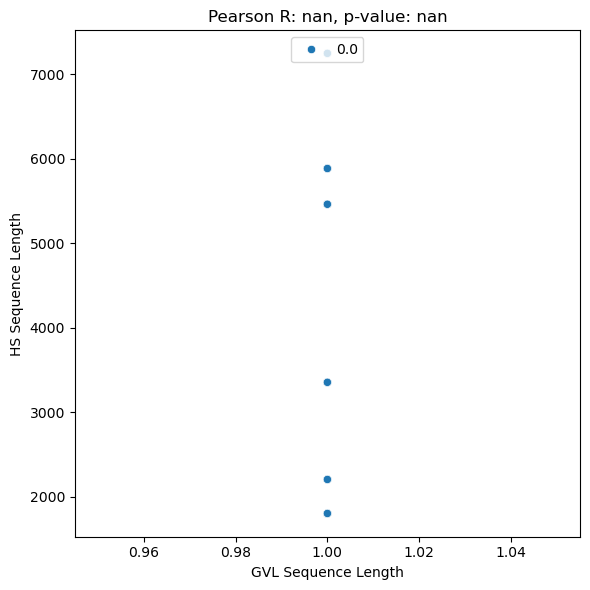

In [31]:
plot_data = seq_sim.loc[(seq_sim['group1'] == 'GVL') & (seq_sim['group2'] == 'HS')]

# Calculate Pearson correlation coefficient and p-value
from scipy.stats import pearsonr
r, p = pearsonr(plot_data['seq1_len'], plot_data['seq2_len'])
title = f'Pearson R: {r:.4f}, p-value: {p:.4e}'

# Create scatter plot with correlation info in title
plt.figure(figsize=(6, 6))
scatter = sns.scatterplot(data=plot_data, 
                          x='seq1_len', y='seq2_len', hue='seq_sim')
plt.title(title)
# Move the legend to the top and make it horizontal
plt.legend(loc='upper center')
plt.xlabel('GVL Sequence Length')
plt.ylabel('HS Sequence Length')
plt.tight_layout()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

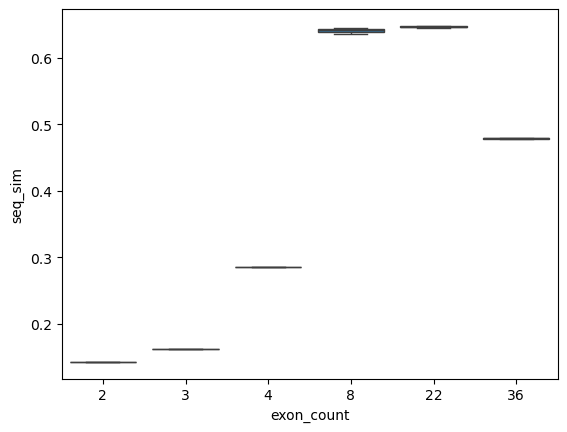

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
scatter = sns.boxplot(data=plot_data, 
                      x='exon_count', y='seq_sim')
                          

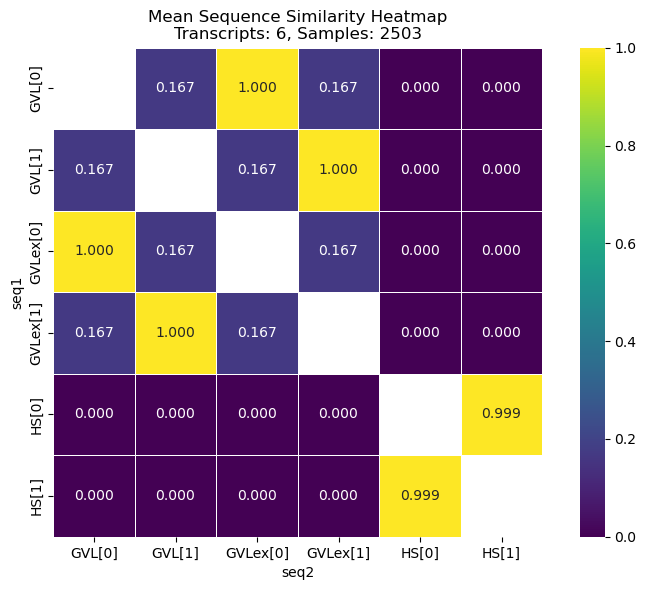

/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [32]:
# Create a pivot table for the heatmap
mean_sim_mtx = seq_sim.groupby(['seq1', 'seq2']).agg({'seq_sim': 'mean'}).reset_index().pivot_table(
    index='seq1', 
    columns='seq2', 
    values='seq_sim'
)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(mean_sim_mtx, annot=True, cmap='viridis', vmin=0, vmax=1, 
            linewidths=.5, fmt='.3f', square=True)
plt.title(f'Mean Sequence Similarity Heatmap\nTranscripts: {seq_sim['transcript_id'].nunique()}, Samples: {seq_sim['sample'].nunique()}')
plt.tight_layout()
plt.show()


/grid/koo/home/schilder/.conda/envs/genome-loader/lib/python3.12/site-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<Figure size 600x1000 with 0 Axes>

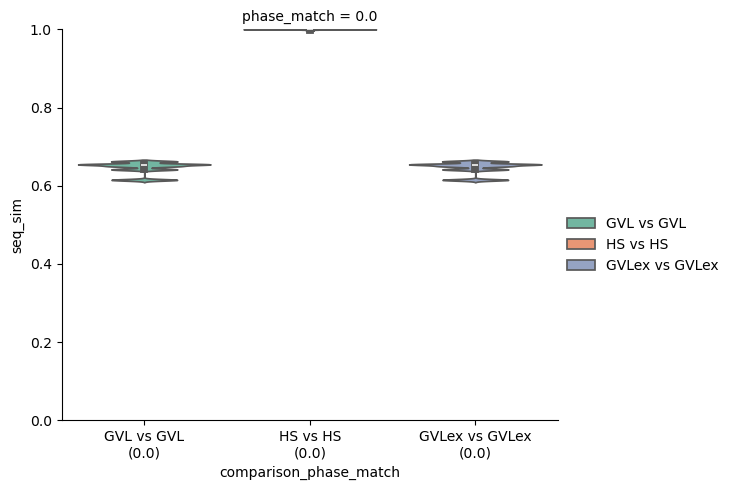

In [32]:
import numpy as np
# Sort the groups alphabetically to make the comparison invariant to order
seq_sim['comparison'] = np.where(
    seq_sim['group1'] < seq_sim['group2'],
    seq_sim['group1'] + ' vs ' + seq_sim['group2'],
    seq_sim['group2'] + ' vs ' + seq_sim['group1']
)
seq_sim['comparison_phase_match'] = seq_sim['comparison'] + '\n(' + seq_sim['phase_match'].astype(str) + ')'

# Create separate violin plots for each phase_match value
plt.figure(figsize=(6, 10))

# Alternatively, we can create a facetgrid to show separate plots by phase_match
g = sns.FacetGrid(seq_sim, row='phase_match', height=5, aspect=1.2)
g.map_dataframe(sns.violinplot, x='comparison_phase_match', y='seq_sim', hue='comparison', palette="Set2")
g.set(ylim=(0, 1))  # Set y-axis limits from 0 to 1
g.add_legend()
